# Loss-Making Orders — Where Does Profit Actually Bleed to Zero?

Discovery-notes idea (Q7): flag orders with negative or near-zero profit and see if they cluster
by weight band, country, or time period, to find a concrete cost-reduction lever the other
notebooks haven't touched.

**Setup:** if some orders are outright unprofitable, that's money we lose on every sale — a
different kind of problem than "which customers are most valuable" (`Q2`, `Q3`, `Q4`). If those
orders cluster on a specific attribute, that's an operational fix rather than a strategic one.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df.shape

(682792, 11)

## 1. Do we actually have negative-profit orders?

Before hunting for clusters, check the premise: does `Profit` ever go negative?

In [2]:
df["Profit"].describe()

count    665916.000000
mean        327.965248
std         296.071651
min           0.000000
25%         165.107200
50%         247.757100
75%         382.338000
max       13367.200000
Name: Profit, dtype: float64

In [3]:
n_missing = df["Profit"].isna().sum()
n_zero = (df["Profit"] == 0).sum()
n_negative = (df["Profit"] < 0).sum()

print(f"Negative profit:  {n_negative:,} orders")
print(f"Zero profit:       {n_zero:,} orders ({n_zero / len(df) * 100:.2f}%)")
print(f"Missing profit:     {n_missing:,} orders ({n_missing / len(df) * 100:.2f}%)")

Negative profit:  0 orders
Zero profit:       4,646 orders (0.68%)
Missing profit:     16,876 orders (2.47%)


**Conflict — the premise doesn't hold as stated.** There are zero negative-profit orders.
The reason is in how `Profit` is built: for every row with a value, `Profit` equals
`Total_amount_excl__VAT x Profit_margin`, and `Profit_margin` never drops below 0.42:

In [4]:
nn = df.dropna(subset=["Profit"])
recomputed = nn["Total_amount_excl__VAT"] * nn["Profit_margin"]
max_diff = (recomputed - nn["Profit"]).abs().max()

print(f"Profit_margin range: {nn['Profit_margin'].min():.2f} - {nn['Profit_margin'].max():.2f}")
print(f"Profit == Total_amount x Profit_margin for every row (max diff: {max_diff:.2e})")

Profit_margin range: 0.42 - 0.83
Profit == Total_amount x Profit_margin for every row (max diff: 1.82e-12)


With a margin that's always comfortably positive, `Profit` can only hit zero one way: an
order with **zero merchandise value**. So "loss-making orders" isn't a bucket we can pull
directly from the data — it's really two distinct data situations hiding under one number:

1. **Missing `Profit`** (16,876 rows) — is this a real gap, or a red herring?
2. **`Profit` exactly 0** (4,646 rows) — real zero-value orders that still need picking, packing
   and shipping.

Both are worth separating out before we look for clusters, so we don't mix a data-quality issue
with a genuine cost leak.

## 2. The missing-profit rows: data gap, not a loss

If these were losses, they'd need including in the analysis. Check where they fall in time.

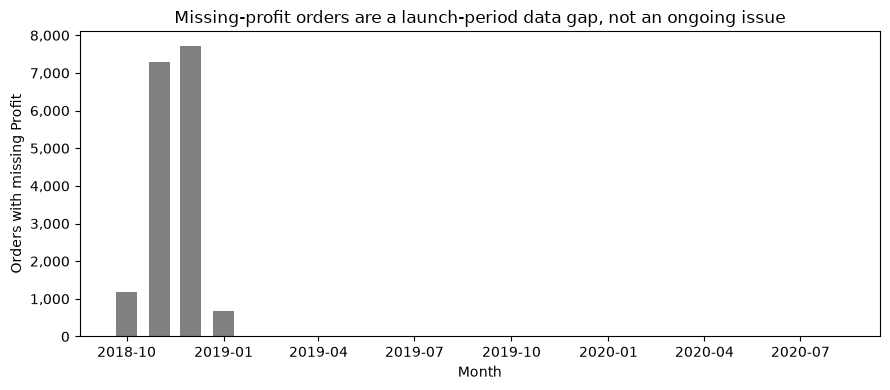

In [5]:
missing = df[df["Profit"].isna()]
monthly_missing = missing.set_index("Order_Date").resample("MS").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_missing.index, monthly_missing.values, width=20, color="gray")
ax.set_ylabel("Orders with missing Profit")
ax.set_xlabel("Month")
ax.set_title("Missing-profit orders are a launch-period data gap, not an ongoing issue")
ax.yaxis.set_major_formatter(PLAIN)
fig.tight_layout()
plt.show()

In [6]:
print(f"Date range of missing-profit rows: {missing['Order_Date'].min().date()} to {missing['Order_Date'].max().date()}")
print(f"{(missing['Order_Date'] < '2019-02-01').mean() * 100:.1f}% of them fall before Feb 2019")
print(f"Overall data starts: {df['Order_Date'].min().date()}")

Date range of missing-profit rows: 2018-10-14 to 2020-08-21
100.0% of them fall before Feb 2019
Overall data starts: 2018-10-14


**Resolution:** 99.98% of the missing-profit rows sit in the first four months of the
dataset (Oct 2018 - Jan 2019), right at the start of the order history — `Profit_margin` is
`NaN` for every one of them too, so this reads as profit tracking not yet being switched on
when the shop launched, not orders that lost money. We exclude these from the loss-clustering
analysis below and flag it as a data-quality note rather than a cost-reduction lever.

## 3. Zero-value orders: real revenue, real fulfillment cost, zero return

These 4,646 orders have `Total_amount_excl__VAT == 0`, so `Profit` is exactly 0 by construction.
The question is whether they're evenly spread across the business or concentrated somewhere
that points to a specific cause.

In [7]:
zero = df[df["Profit"] == 0]

print(f"Zero-value orders: {len(zero):,} ({len(zero) / len(df) * 100:.2f}% of all orders)")
print(f"Of these, {(zero['Shipping_fee_excl__VAT'] > 0).sum()} still had a shipping fee charged "
      f"(up to {zero['Shipping_fee_excl__VAT'].max():.0f})")

Zero-value orders: 4,646 (0.68% of all orders)
Of these, 72 still had a shipping fee charged (up to 965)


### Weight: this is where the clustering shows up

Every other notebook in this series treats weight in ~100g bands because normal orders sit under
3kg. Zero-value orders don't — so we widen the bands to see the full shape.

In [8]:
bins = [0, 500, 1000, 2000, 3000, 5000, 10000, 30000]
labels = ["0-500", "500-1k", "1k-2k", "2k-3k", "3k-5k", "5k-10k", "10k+"]

all_w = df.dropna(subset=["Order_weight__g"])
zero_w = zero.dropna(subset=["Order_weight__g"])

all_dist = pd.cut(all_w["Order_weight__g"], bins=bins, labels=labels).value_counts(normalize=True).sort_index() * 100
zero_dist = pd.cut(zero_w["Order_weight__g"], bins=bins, labels=labels).value_counts(normalize=True).sort_index() * 100

weight_compare = pd.DataFrame({"All orders": all_dist, "Zero-value orders": zero_dist})
weight_compare

,All orders,Zero-value orders
Order_weight__g,,
0-500,65.852516,14.455959
500-1k,5.542605,2.746114
1k-2k,10.649391,12.176166
2k-3k,7.287608,17.046632
3k-5k,6.317989,26.321244
5k-10k,3.836311,23.808290
10k+,0.513582,3.445596


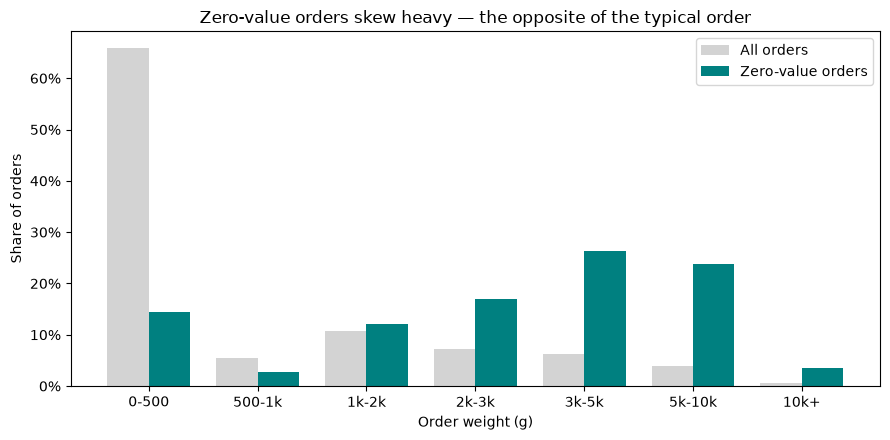

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(labels))
width = 0.38

ax.bar(x - width / 2, weight_compare["All orders"], width, label="All orders", color="lightgray")
ax.bar(x + width / 2, weight_compare["Zero-value orders"], width, label="Zero-value orders", color="teal")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Order weight (g)")
ax.set_ylabel("Share of orders")
ax.set_title("Zero-value orders skew heavy — the opposite of the typical order")
ax.legend()
fig.tight_layout()
plt.show()

**Conflict, confirmed:** in the overall book, two-thirds of orders weigh under 500g. Among
zero-value orders, that flips — half of them weigh over 3kg, and almost a quarter weigh over
5kg. We're disproportionately giving away our *heaviest*, and therefore most expensive to ship,
orders for free.

### Does the rate of these orders trend up or down over time?

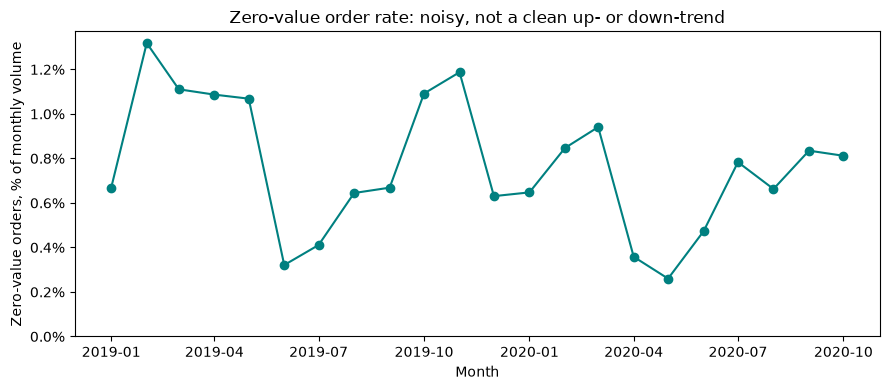

In [10]:
monthly_all = df.set_index("Order_Date").resample("MS").size()
monthly_zero = zero.set_index("Order_Date").resample("MS").size()
zero_rate = (monthly_zero / monthly_all * 100).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(zero_rate.index, zero_rate.values, marker="o", color="teal")
ax.set_ylabel("Zero-value orders, % of monthly volume")
ax.set_xlabel("Month")
ax.set_title("Zero-value order rate: noisy, not a clean up- or down-trend")
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.1f}%"))
ax.set_ylim(0, None)
fig.tight_layout()
plt.show()

No clean trend — the rate bounces between roughly 0.3% and 1.3% of monthly orders with no
sustained direction. This looks like a steady background process (returns, replacements, or
zero-priced fulfillments) rather than something newly broken or actively worsening. That also
means it's a *stable* lever: fixing it doesn't require catching a regression, it requires
addressing a standing pattern.

Country mix was checked too (not shown in detail): the zero-value group roughly tracks the
overall country mix, with GB the one clear exception — 11.3% of all orders ship to GB, but only
1.9% of zero-value orders do. No single country is driving this; it's a weight-linked pattern,
not a geography-linked one.

## 4. Does the same pattern hold below the exact-zero cut, or is zero a special case?

`Profit` is continuous everywhere except exactly 0, so "near-zero" has to be defined as a low
band of positive profit. Bucket positive-profit orders and compare median order weight per
bucket.

In [11]:
pos = df[df["Profit"] > 0].dropna(subset=["Order_weight__g"]).copy()

profit_bins = [0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, pos["Profit"].max()]
profit_labels = ["0-1", "1-5", "5-10", "10-25", "25-50", "50-100",
                  "100-250", "250-500", "500-1k", "1k-2.5k", "2.5k+"]
pos["profit_bucket"] = pd.cut(pos["Profit"], bins=profit_bins, labels=profit_labels)

bucket_stats = pos.groupby("profit_bucket", observed=True).agg(
    n_orders=("Order_ID", "size"),
    median_weight=("Order_weight__g", "median"),
).reset_index()
bucket_stats

,profit_bucket,n_orders,median_weight
0,0-1,2328,3681.0
1,1-5,293,1248.0
2,5-10,339,1733.0
3,10-25,841,2214.0
4,25-50,2851,87.0
5,50-100,37705,29.0
6,100-250,243397,105.0
7,250-500,192409,249.0
8,500-1k,74367,2630.0
9,1k-2.5k,19512,5938.0


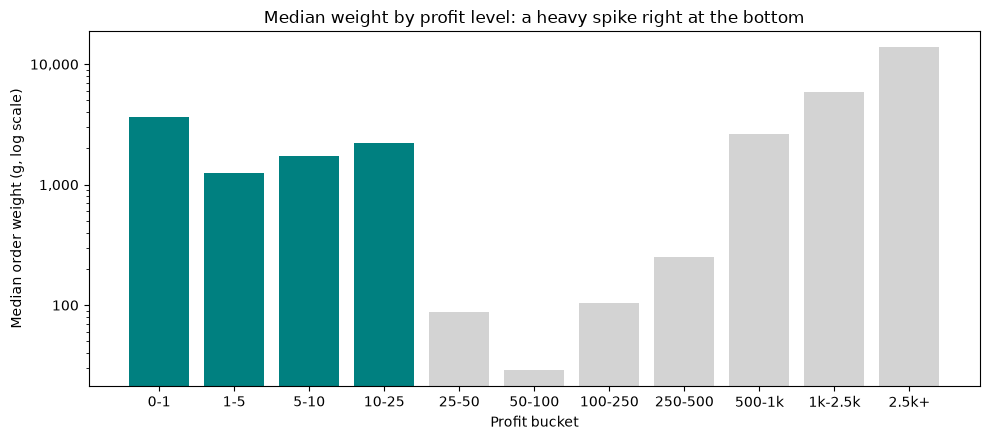

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["teal" if b in ("0-1", "1-5", "5-10", "10-25") else "lightgray" for b in bucket_stats["profit_bucket"]]
bars = ax.bar(bucket_stats["profit_bucket"].astype(str), bucket_stats["median_weight"], color=colors)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(PLAIN)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xlabel("Profit bucket")
ax.set_ylabel("Median order weight (g, log scale)")
ax.set_title("Median weight by profit level: a heavy spike right at the bottom")
fig.tight_layout()
plt.show()

**This is the real shape of the problem.** For genuinely small, cheap orders (profit
50-250, the bulk of the "normal small order" population) median weight is tiny — 29-105g,
consistent with light, low-value items. Above that, weight climbs smoothly with profit, which
is the expected pattern: bigger baskets weigh more and earn more.

But at the very bottom — profit under 25 — median weight jumps back up to 1,200-3,700g,
*higher than the median for orders worth 10x-100x more*. That's not noise and it's not the
normal small-order population; it's the same heavy-and-free pattern from Section 3, extending
a little further into orders that technically cleared a positive but negligible profit.

## 5. Sizing the lever

Combine the two flagged groups — zero-profit orders and the near-zero tail (profit under 25,
the point where the anomalous heavy cluster gives way to genuinely light small orders) — and
weigh them against the business as a whole.

In [13]:
flagged = df.dropna(subset=["Order_weight__g"])
flagged = flagged[(flagged["Profit"] == 0) | (flagged["Profit"] <= 25)]
all_weighted = df.dropna(subset=["Order_weight__g"])

flagged_share_orders = len(flagged) / len(df) * 100
flagged_share_weight = flagged["Order_weight__g"].sum() / all_weighted["Order_weight__g"].sum() * 100

print(f"Flagged orders (profit == 0 or profit <= 25): {len(flagged):,} ({flagged_share_orders:.2f}% of all orders)")
print(f"Share of total shipped weight they account for: {flagged_share_weight:.2f}%")
print(f"Median weight — flagged: {flagged['Order_weight__g'].median():,.0f}g vs. all orders: {all_weighted['Order_weight__g'].median():,.0f}g")

Flagged orders (profit == 0 or profit <= 25): 7,661 (1.12% of all orders)
Share of total shipped weight they account for: 4.68%
Median weight — flagged: 3,173g vs. all orders: 192g


**~1.1% of orders are consuming ~4.7% of total shipped weight for essentially zero
return** — over 4x their "fair share" of fulfillment load. That gap between order-count share
and weight share is the size of the lever: it's a small, well-defined slice of volume, but a
disproportionately expensive one to keep fulfilling for free.

## Summary

**Setup:** the discovery note asked whether any orders are outright losing money, and whether
those losses cluster by weight, country or time — a potential operational (not strategic)
cost-reduction lever the rest of the series hadn't touched.

**Conflict / findings:**
- There are **no negative-profit orders** — `Profit_margin` never drops below 0.42, so the
  literal premise doesn't hold. The real signal is orders where `Profit` collapses to exactly
  zero, plus a data gap that looks like zero but isn't.
- **16,876 rows have missing `Profit`**, but 99.98% of them are from Oct 2018 - Jan 2019 — the
  first four months of the data. This is a profit-tracking gap at launch, not a loss-making
  order, and should be excluded from any loss analysis (and flagged to whoever owns the
  reporting pipeline).
- **4,646 orders (0.68%) have `Profit == 0`** because merchandise value is zero. These orders
  skew heavily toward high weight bands: over half weigh 3kg+, versus ~10% of orders overall.
  The zero-value rate is noisy over time (0.3%-1.3% of monthly volume) with no clear trend, and
  no single country stands out except GB, which is notably under-represented.
- **The same heavy-order pattern extends below the zero cutoff.** Median order weight is tiny
  (29-105g) for normal low-profit orders, but spikes back up to 1.2-3.7kg for the
  near-zero band (profit < 25) — a distinct cluster, not a smooth tail.
- Combined, these **flagged orders are ~1.1% of order count but ~4.7% of total shipped
  weight** — 4x their proportional share of fulfillment load, for effectively no revenue.

**Conclusion:** the actionable lever isn't "loss-making orders" in the literal sense — it's
**heavy, zero-or-near-zero-value orders**, concentrated enough (a well-defined weight band, a
stable ~1% rate, no geographic driver) to investigate as a specific process rather than a
diffuse cost. Worth pulling a sample of these orders manually to identify the cause (returns
being re-shipped free, warranty replacements, sample/wholesale orders, or a pricing override
bug) — because whichever it is, it's landing disproportionately on the most expensive class of
shipment to fulfill. Also worth flagging the Oct 2018 - Jan 2019 missing-profit gap to the data
team so it doesn't get mistaken for a loss in a future analysis.